# Credit Card Fraud Detection — ML Pipeline

**Goal:** Build a leakage-free machine-learning pipeline for detecting fraudulent credit-card transactions in a highly imbalanced dataset.
- Proper preprocessing with `Pipeline` / `imblearn.Pipeline`.
- Compare **class-weighted** and **SMOTE-based** approaches.
- Evaluate with **Precision, Recall, F1, ROC-AUC and PR-AUC**
- Hyperparameter tuning using **StratifiedKFold** and **average precision (PR-AUC)**.
- Decision-threshold analysis to make the fraud/normal trade-off explicit.
- Final confusion matrix and feature-importance analysis.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")


## 1. Load the Dataset

In [2]:
data = pd.read_csv("creditcard.csv")

print("Shape:", data.shape)
display(data.head())


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Data Quality and Class Distribution

In [3]:
print(data.info())
print("\nMissing values:")
display(data.isnull().sum().to_frame("missing_values").T)

print("\nClass distribution:")
display(data["Class"].value_counts().rename(index={0: "Normal", 1: "Fraud"}))

fraud_rate = data["Class"].mean() * 100
print(f"Fraud rate: {fraud_rate:.4f}%")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Class distribution:


,count
Class,
Normal,284315
Fraud,492


Fraud rate: 0.1727%


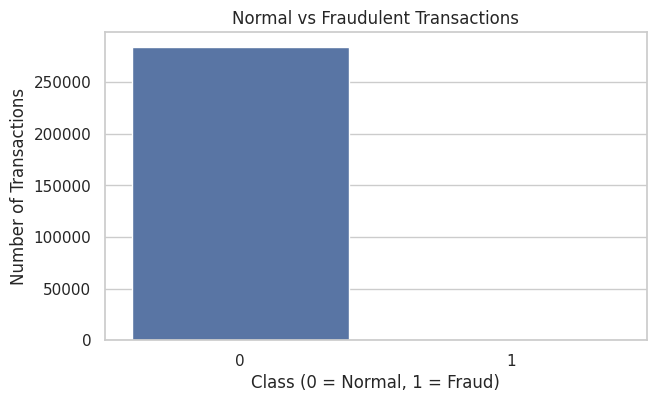

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(x="Class", data=data)
plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()



Fraud is a rare class, so a model can obtain very high accuracy while still missing many fraudulent transactions.  
For this reason, the main evaluation metrics in this notebook are **Precision, Recall, F1-score, ROC-AUC and PR-AUC (Average Precision)**.


## 3. Features and Perform a Leakage-Free Split

In [5]:
# Remove rows with missing target values, if any
data = data.dropna(subset=["Class"]).copy()

X = data.drop(columns=["Class"])
y = data["Class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())


Training shape: (227845, 30)
Test shape: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


Scaling and SMOTE are deliberately applied **inside the training pipeline**.  
This prevents information from the test set from influencing preprocessing or synthetic samples.


## 4. Baseline: Logistic Regression with Class Weights

In [6]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

logistic_pipeline.fit(X_train, y_train)

lr_pred = logistic_pipeline.predict(X_test)
lr_prob = logistic_pipeline.predict_proba(X_test)[:, 1]


## 5. SMOTE-Based Logistic Regression

In [7]:
# SMOTE is applied only to the training fold inside the pipeline.
smote_logistic = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

smote_logistic.fit(X_train, y_train)

smote_pred = smote_logistic.predict(X_test)
smote_prob = smote_logistic.predict_proba(X_test)[:, 1]


## 6. Random Forest with Class Weights

In [9]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=250,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]


## 7. Model Evaluation

In [10]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression (Class Weight)", y_test, lr_pred, lr_prob),
    evaluate_model("Logistic Regression (SMOTE)", y_test, smote_pred, smote_prob),
    evaluate_model("Random Forest (Class Weight)", y_test, rf_pred, rf_prob)
])

results.sort_values("PR-AUC", ascending=False).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest (Class Weight),0.999526,0.949367,0.765306,0.847458,0.946727,0.860711
1,Logistic Regression (SMOTE),0.974141,0.057878,0.918367,0.108893,0.970809,0.722533
2,Logistic Regression (Class Weight),0.975545,0.061017,0.918367,0.114431,0.972093,0.718935


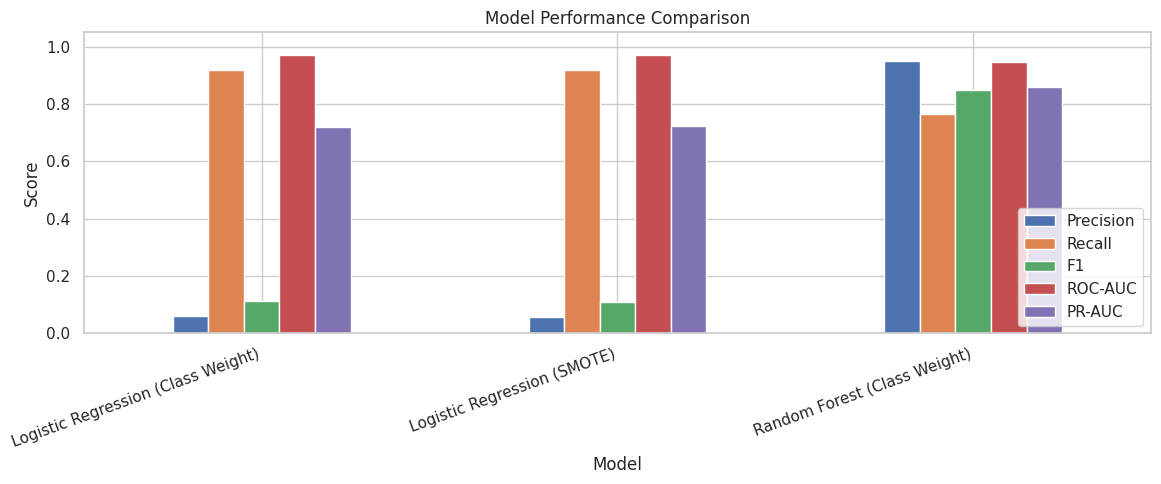

In [11]:
# Visual comparison
plot_df = results.set_index("Model")[["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]]
plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 8. Precision-Recall Curves

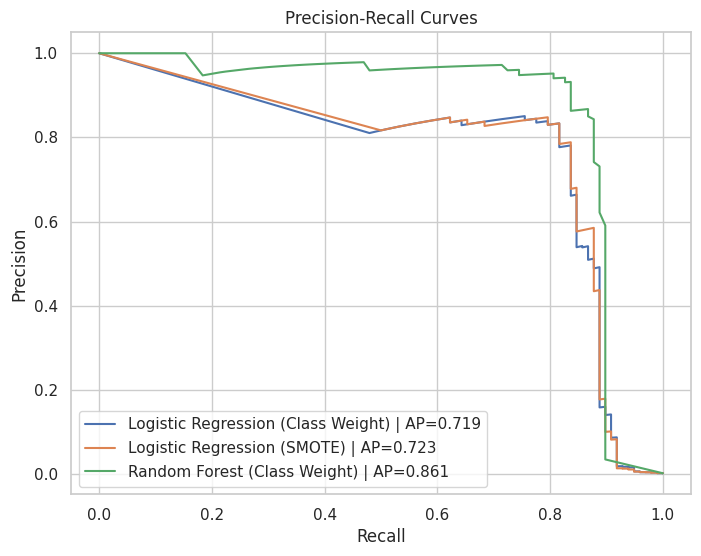

In [12]:
plt.figure(figsize=(8, 6))

for name, prob in [
    ("Logistic Regression (Class Weight)", lr_prob),
    ("Logistic Regression (SMOTE)", smote_prob),
    ("Random Forest (Class Weight)", rf_prob)
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} | AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()


## 9. Hyperparameter Tuning — Random Forest

In [14]:
# Faster Random Forest Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions={
        "n_estimators": [80, 120, 160],
        "max_depth": [None, 10, 15],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    },
    n_iter=6,
    scoring="average_precision",
    cv=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)
print(f"Best CV PR-AUC: {rf_search.best_score_:.4f}")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best parameters:
{'n_estimators': 120, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV PR-AUC: 0.8284


In [15]:
best_rf = rf_search.best_estimator_

tuned_prob = best_rf.predict_proba(X_test)[:, 1]
tuned_pred = (tuned_prob >= 0.50).astype(int)

tuned_result = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_pred,
    tuned_prob
)

pd.DataFrame([tuned_result])


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned Random Forest,0.999526,0.961039,0.755102,0.845714,0.952537,0.8598


## 10. Decision Threshold Analysis

,Threshold,Precision,Recall,F1
0,0.10,0.704918,0.877551,0.781818
1,0.15,0.792453,0.857143,0.823529
2,0.20,0.821782,0.846939,0.834171
3,0.25,0.845361,0.836735,0.841026
4,0.30,0.910112,0.826531,0.866310
5,0.35,0.930233,0.816327,0.869565
6,0.40,0.951807,0.806122,0.872928
7,0.45,0.950000,0.775510,0.853933
8,0.50,0.961039,0.755102,0.845714
9,0.55,0.960526,0.744898,0.839080


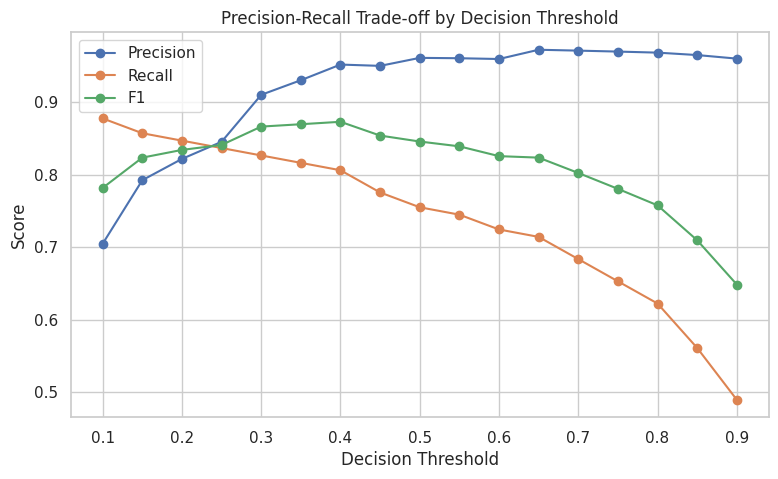

In [16]:
# The default 0.50 threshold is not always appropriate for fraud detection.
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_rows = []

for threshold in thresholds:
    pred = (tuned_prob >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()


## 11. Select an F1-Based Threshold

In [17]:
best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = float(best_threshold_row["Threshold"])

final_pred = (tuned_prob >= best_threshold).astype(int)

print(f"Selected threshold: {best_threshold:.2f}")
print(classification_report(y_test, final_pred, target_names=["Normal", "Fraud"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, tuned_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, tuned_prob):.4f}")


Selected threshold: 0.40
              precision    recall  f1-score   support

      Normal     0.9997    0.9999    0.9998     56864
       Fraud     0.9518    0.8061    0.8729        98

    accuracy                         0.9996     56962
   macro avg     0.9757    0.9030    0.9364     56962
weighted avg     0.9996    0.9996    0.9996     56962

ROC-AUC: 0.9525
PR-AUC:  0.8598


## 12. Final Confusion Matrix

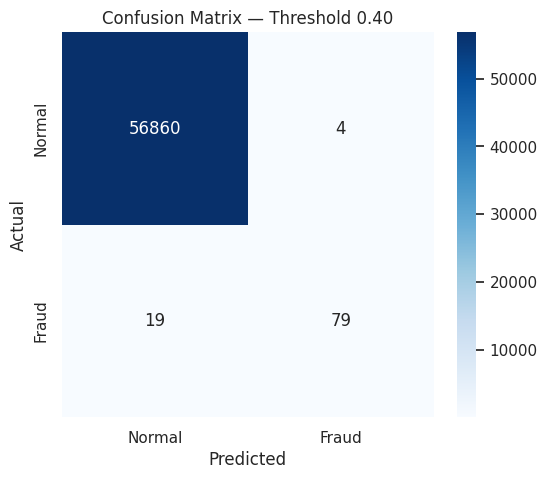

In [18]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.title(f"Confusion Matrix — Threshold {best_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 13. Feature Importance

,importance
V14,0.177724
V10,0.132444
V4,0.105140
V12,0.103760
V17,0.086558
V3,0.061582
V11,0.046429
V16,0.037951
V2,0.034897
V7,0.027356


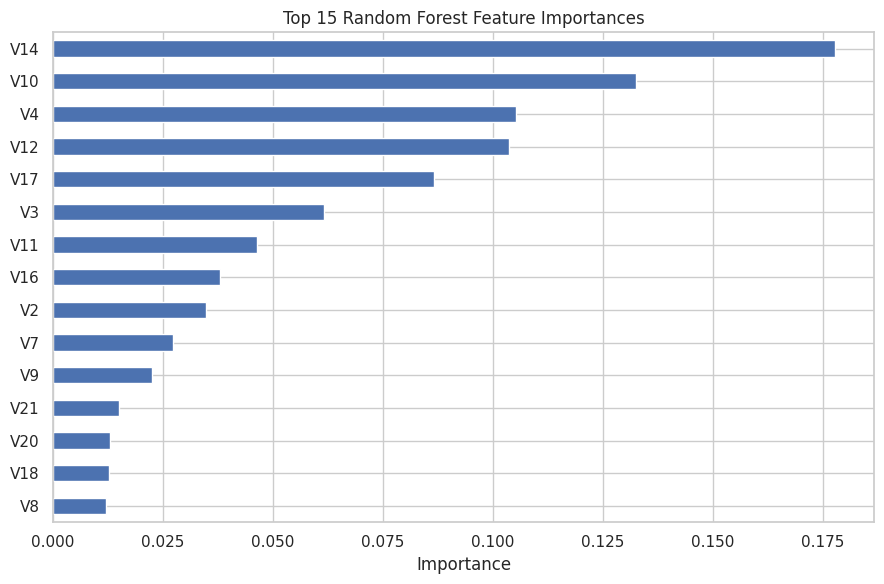

In [19]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(feature_importance.head(15).to_frame("importance"))

plt.figure(figsize=(9, 6))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 14. Key Findings

- The dataset is highly imbalanced, so accuracy alone is not a reliable measure of fraud-detection quality.
- Scaling is fitted only on training data to avoid leakage.
- SMOTE is applied only inside the training pipeline.
- Model selection emphasizes **PR-AUC, recall, precision and F1-score**.
- The decision threshold is explicitly analyzed because fraud detection involves a precision–recall trade-off.
- The tuned Random Forest is evaluated on the untouched test set only after model selection.


## 15. Reproducibility Notes

- Dataset file expected: `creditcard.csv`
- Target column: `Class`
- Random seed: `42`

